In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Create plots folder in the MAIN directory (parent folder)
# Since notebook is in 'notebooks/' folder, we need to go up one level
plots_dir = '../plots'  # This goes up one level from notebooks folder

if not os.path.exists(plots_dir):
    os.makedirs(plots_dir)
    print(f"Created 'plots' folder at: {plots_dir}")

# Set professional style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

# Load cleaned data (file is in data/ folder at main level)
df = pd.read_csv("../Data/cleaned_students.csv")
print("Data loaded successfully!")
print(df.head())

Data loaded successfully!
   gender race/ethnicity parental level of education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test preparation course  math score  reading score  writing score  
0                    none        72.0           72.0           74.0  
1               completed        69.0           90.0           88.0  
2                    none        90.0           95.0           93.0  
3                    none        47.0           57.0           44.0  
4                    none        76.0           78.0           75.0  


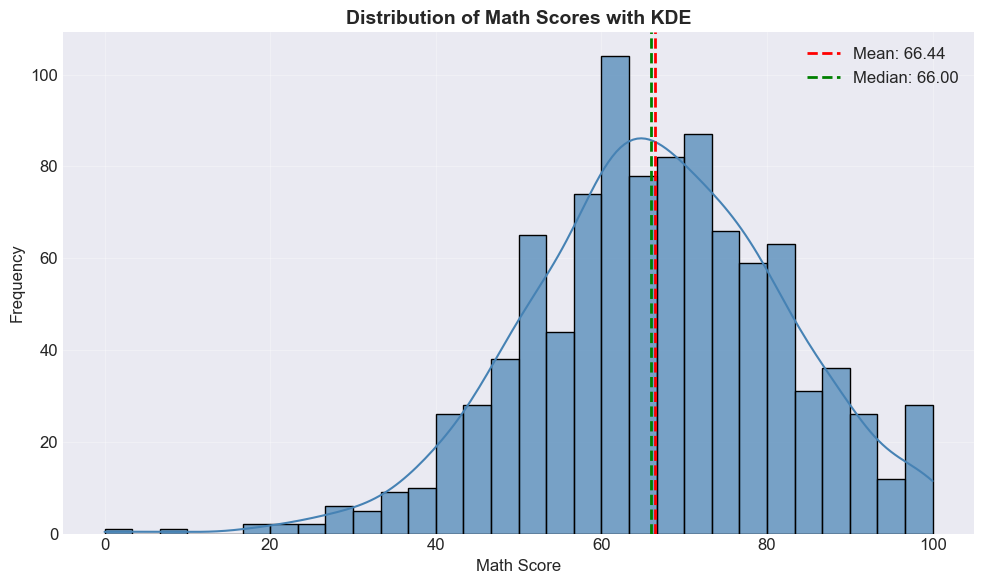

✓ Saved: ../plots/plot1_histogram_math.png


In [5]:
fig1, ax1 = plt.subplots(figsize=(10, 6))

sns.histplot(data=df, x='math score', kde=True, bins=30, 
             color='steelblue', edgecolor='black', alpha=0.7)

# Add mean and median lines
mean_math = df['math score'].mean()
median_math = df['math score'].median()
ax1.axvline(mean_math, color='red', linestyle='--', linewidth=2, 
            label=f'Mean: {mean_math:.2f}')
ax1.axvline(median_math, color='green', linestyle='--', linewidth=2,
            label=f'Median: {median_math:.2f}')

ax1.set_title('Distribution of Math Scores with KDE', fontsize=14, fontweight='bold')
ax1.set_xlabel('Math Score', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.legend(loc='upper right')
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/plot1_histogram_math.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ../plots/plot1_histogram_math.png")

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_4048\3248022434.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='gender', y='math score', palette='Set2', ax=ax2)


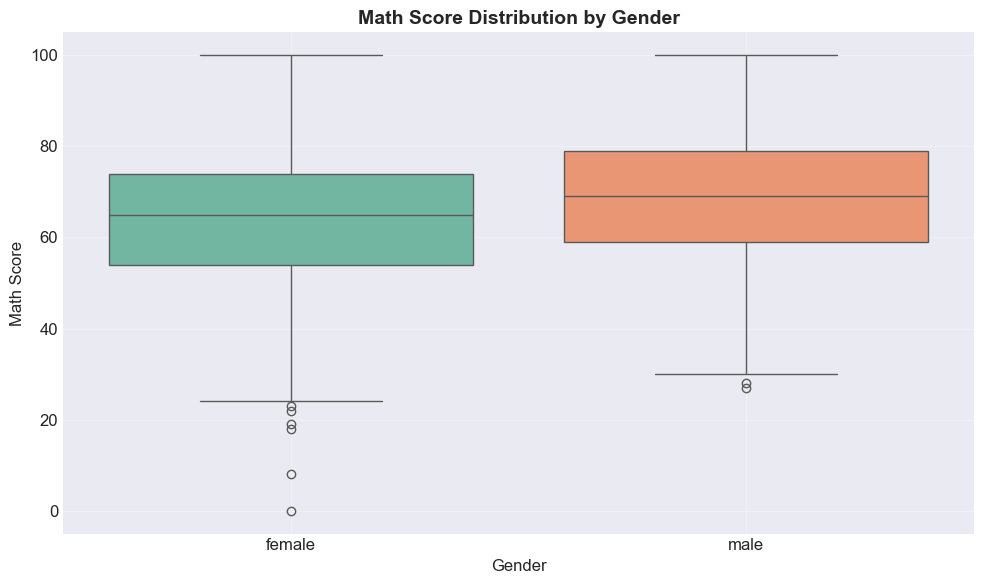

✓ Saved: ../plots/plot2_boxplot_math_gender.png


In [6]:
fig2, ax2 = plt.subplots(figsize=(10, 6))

sns.boxplot(data=df, x='gender', y='math score', palette='Set2', ax=ax2)

ax2.set_title('Math Score Distribution by Gender', fontsize=14, fontweight='bold')
ax2.set_xlabel('Gender', fontsize=12)
ax2.set_ylabel('Math Score', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/plot2_boxplot_math_gender.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ../plots/plot2_boxplot_math_gender.png")

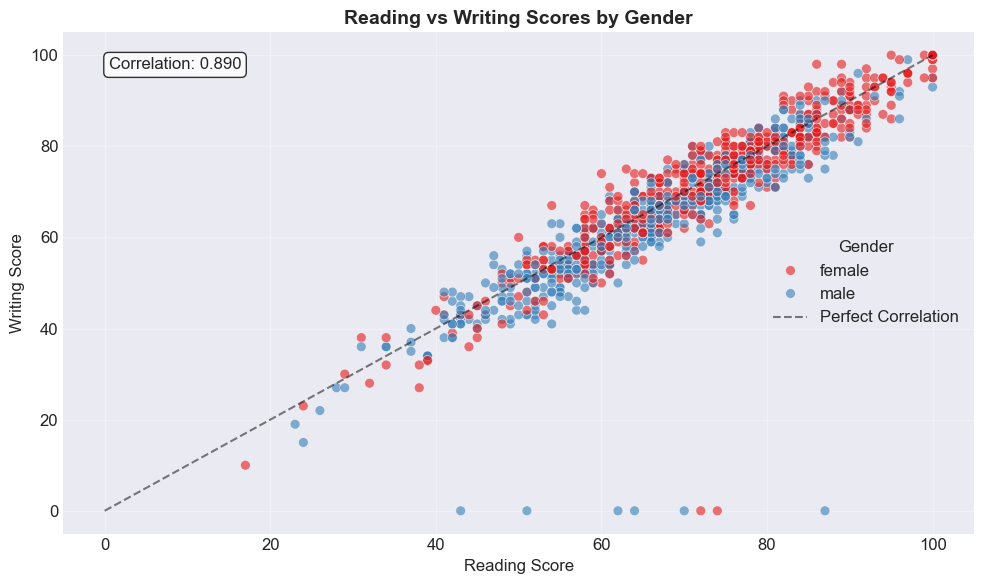

✓ Saved: ../plots/plot3_scatter_reading_writing.png


In [7]:
fig3, ax3 = plt.subplots(figsize=(10, 6))

scatter = sns.scatterplot(data=df, x='reading score', y='writing score', 
                          hue='gender', alpha=0.6, s=50, palette='Set1', ax=ax3)

# Add perfect correlation line
ax3.plot([0, 100], [0, 100], 'k--', alpha=0.5, label='Perfect Correlation')

# Calculate correlation
corr = df['reading score'].corr(df['writing score'])
ax3.text(0.05, 0.95, f'Correlation: {corr:.3f}', transform=ax3.transAxes,
         fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax3.set_title('Reading vs Writing Scores by Gender', fontsize=14, fontweight='bold')
ax3.set_xlabel('Reading Score', fontsize=12)
ax3.set_ylabel('Writing Score', fontsize=12)
ax3.legend(title='Gender')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/plot3_scatter_reading_writing.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ../plots/plot3_scatter_reading_writing.png")

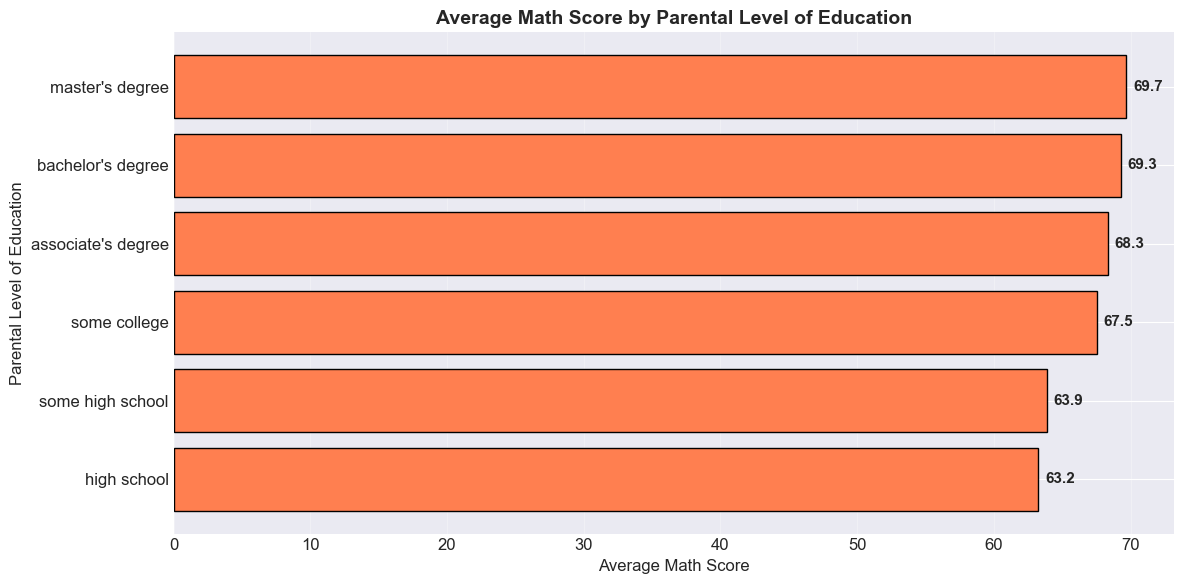

✓ Saved: ../plots/plot4_barchart_parent_education.png


In [8]:
fig4, ax4 = plt.subplots(figsize=(12, 6))

# Calculate averages
parent_math = df.groupby('parental level of education')['math score'].mean().sort_values()

# Create horizontal bar chart
bars = ax4.barh(parent_math.index, parent_math.values, color='coral', edgecolor='black')

# Add value labels
for bar, value in zip(bars, parent_math.values):
    ax4.text(value + 0.5, bar.get_y() + bar.get_height()/2, f'{value:.1f}', 
             va='center', fontweight='bold', fontsize=11)

ax4.set_title('Average Math Score by Parental Level of Education', fontsize=14, fontweight='bold')
ax4.set_xlabel('Average Math Score', fontsize=12)
ax4.set_ylabel('Parental Level of Education', fontsize=12)
ax4.grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('../plots/plot4_barchart_parent_education.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ../plots/plot4_barchart_parent_education.png")

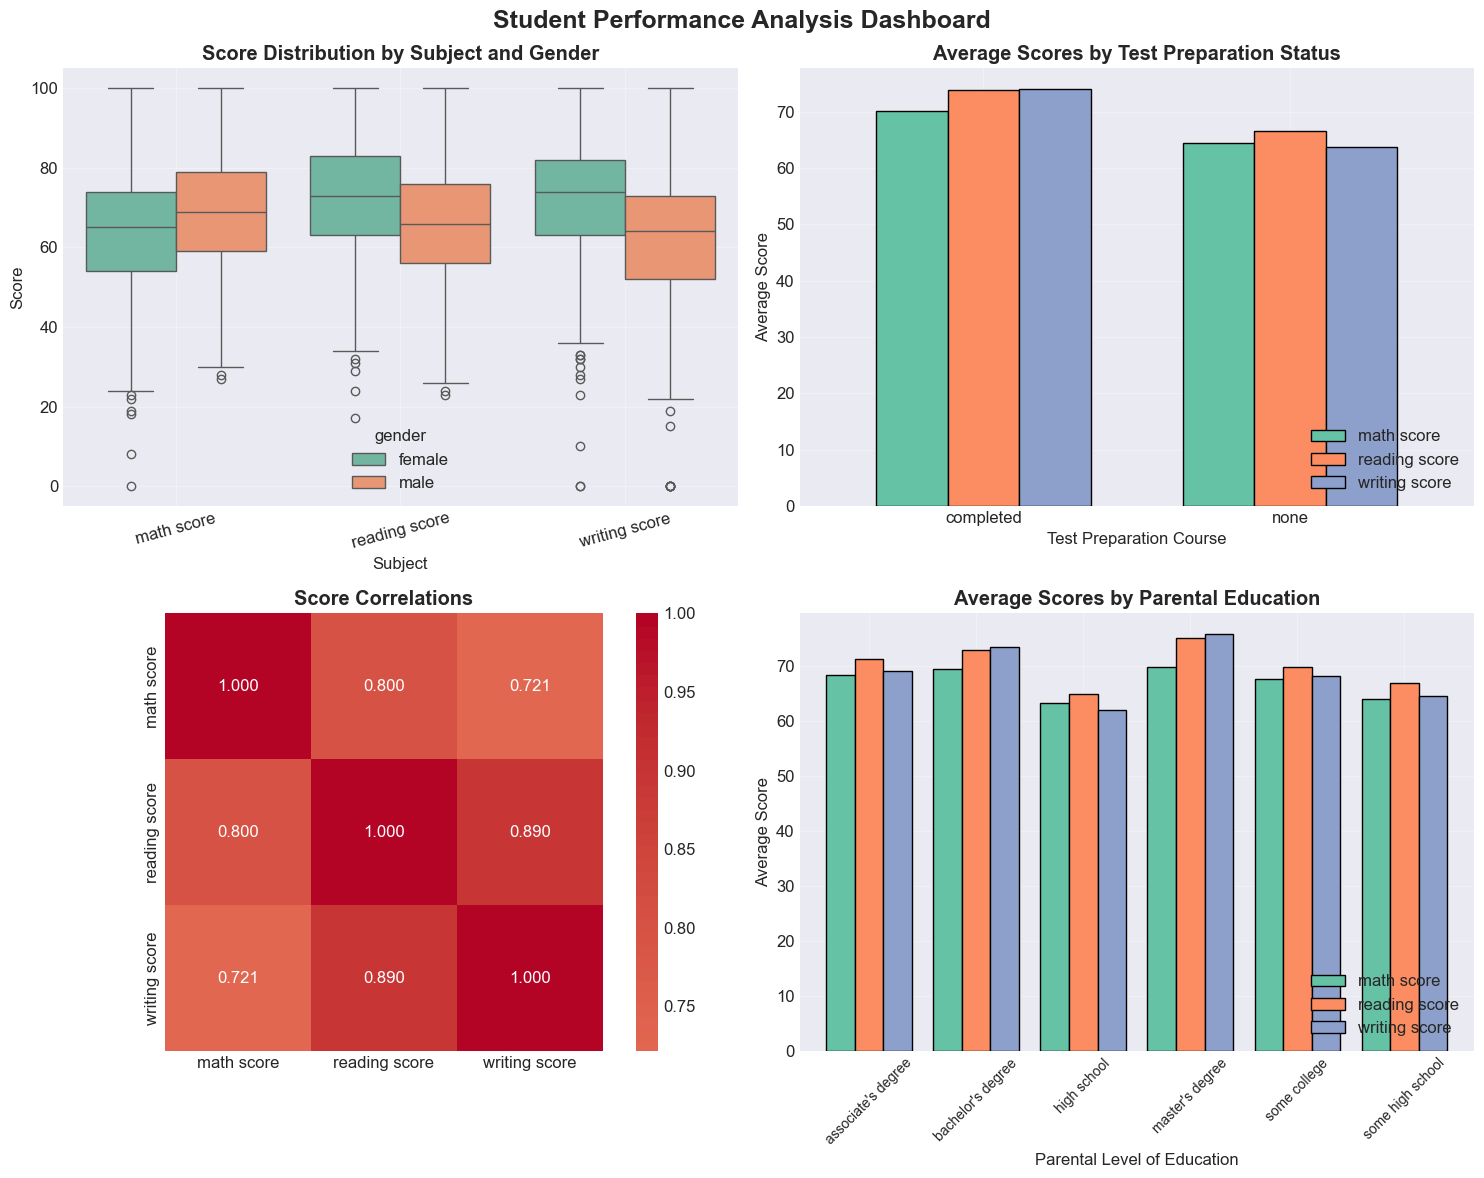

✓ Saved: ../plots/best_visualization.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Student Performance Analysis Dashboard', fontsize=18, fontweight='bold')

# Subplot 1: Boxplot of all subjects by gender
df_melted = pd.melt(df, id_vars=['gender'], 
                    value_vars=['math score', 'reading score', 'writing score'],
                    var_name='Subject', value_name='Score')
sns.boxplot(data=df_melted, x='Subject', y='Score', hue='gender', ax=axes[0,0], palette='Set2')
axes[0,0].set_title('Score Distribution by Subject and Gender', fontweight='bold')
axes[0,0].grid(True, alpha=0.3)
axes[0,0].tick_params(axis='x', rotation=15)

# Subplot 2: Average scores by test preparation
test_prep_scores = df.groupby('test preparation course')[['math score', 'reading score', 'writing score']].mean()
test_prep_scores.plot(kind='bar', ax=axes[0,1], edgecolor='black', width=0.7)
axes[0,1].set_title('Average Scores by Test Preparation Status', fontweight='bold')
axes[0,1].set_xlabel('Test Preparation Course')
axes[0,1].set_ylabel('Average Score')
axes[0,1].legend(loc='lower right')
axes[0,1].grid(True, alpha=0.3)
axes[0,1].tick_params(axis='x', rotation=0)

# Subplot 3: Correlation heatmap
corr_matrix = df[['math score', 'reading score', 'writing score']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            square=True, ax=axes[1,0], fmt='.3f', annot_kws={'size': 12})
axes[1,0].set_title('Score Correlations', fontweight='bold')

# Subplot 4: Average scores by parental education
parent_scores = df.groupby('parental level of education')[['math score', 'reading score', 'writing score']].mean()
parent_scores.plot(kind='bar', ax=axes[1,1], edgecolor='black', width=0.8)
axes[1,1].set_title('Average Scores by Parental Education', fontweight='bold')
axes[1,1].set_xlabel('Parental Level of Education')
axes[1,1].set_ylabel('Average Score')
axes[1,1].legend(loc='lower right')
axes[1,1].grid(True, alpha=0.3)
axes[1,1].tick_params(axis='x', rotation=45, labelsize=10)

plt.tight_layout()
plt.savefig('../plots/best_visualization.png', dpi=300, bbox_inches='tight')
plt.show()
print("✓ Saved: ../plots/best_visualization.png")

In [10]:
print("\n" + "="*50)
print("ALL PLOTS SAVED IN 'plots' FOLDER (Main Directory):")
print("="*50)
import os
plots_path = '../plots'
if os.path.exists(plots_path):
    for file in os.listdir(plots_path):
        if file.endswith('.png'):
            print(f"  • {file}")
else:
    print("Plots folder not found")


ALL PLOTS SAVED IN 'plots' FOLDER (Main Directory):
  • best_visualization.png
  • plot1_histogram_math.png
  • plot2_boxplot_math_gender.png
  • plot3_scatter_reading_writing.png
  • plot4_barchart_parent_education.png
